# Agricultural Futures Final Project

## Corn Futures + MODIS NDVI Overlay MVP

**Project question**

Can a low-frequency vegetation signal from NASA MODIS improve a course-style corn futures trend rule by confirming, weakening, or vetoing technical trades?

**Scope for this first implementation**

- Corn futures only
- One NASA indicator: MODIS NDVI (`MOD13A2`)
- NDVI is treated as a medium-horizon regime filter, not a standalone daily trading engine

This notebook is built to:
1. inspect the local NDVI download inventory
2. back-adjust Yahoo corn futures into an academic continuous series
3. evaluate class-style moving-average rules
4. apply an NDVI overlay only when the data coverage and parser dependencies are sufficient


In [1]:
from pathlib import Path
import os
import re
from datetime import datetime
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/Users/jlaw/projects/stern/systematic-investing/.mplconfig")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path("/Users/jlaw/projects/stern/systematic-investing")
DATA_ROOT = PROJECT_ROOT / "data" / "ag_futures"
RAW_FUTURES_DIR = DATA_ROOT / "raw" / "futures"
RAW_NASA_DIR = DATA_ROOT / "raw" / "nasa" / "mod13a2"
PROCESSED_DIR = DATA_ROOT / "processed"

EARTHDATA_ROOT_CANDIDATES = [
    Path("/Users/jlaw/projects/earthdata_downloads"),
    RAW_NASA_DIR,
]

ROLL_MONTHS = [3, 5, 7, 9, 12]
MA_PAIRS = [(10, 30), (30, 100), (80, 160)]
PRIMARY_PAIR = (30, 100)
MIN_NDVI_FILES = 12
CORN_CACHE_PATH = PROCESSED_DIR / "corn_continuous_back_adjusted.csv"
NDVI_LEVEL_CACHE_PATH = PROCESSED_DIR / "mod13a2_ndvi_level_series.csv"
NDVI_DAILY_CACHE_PATH = PROCESSED_DIR / "mod13a2_ndvi_daily_series.csv"
REFRESH_CORN_FROM_YAHOO = False
REFRESH_NDVI_FROM_RAW = False

for path in [RAW_FUTURES_DIR, RAW_NASA_DIR, PROCESSED_DIR]:
    path.mkdir(parents=True, exist_ok=True)


def pick_first_existing_path(candidates):
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


def parse_modis_vi_date(path):
    match = re.search(r"\.A(\d{4})(\d{3})\.", path.name)
    if not match:
        return pd.NaT
    year = int(match.group(1))
    doy = int(match.group(2))
    return pd.Timestamp(datetime.strptime(f"{year}-{doy:03d}", "%Y-%j"))


def build_ndvi_inventory(root):
    if root is None:
        return pd.DataFrame(columns=["path", "date", "year", "doy", "tile"])
    rows = []
    for path in sorted(root.rglob("MOD13A2*.hdf")):
        date = parse_modis_vi_date(path)
        rows.append(
            {
                "path": str(path),
                "date": date,
                "year": date.year if pd.notna(date) else np.nan,
                "doy": date.dayofyear if pd.notna(date) else np.nan,
                "tile": re.search(r"\.(h\d{2}v\d{2})\.", path.name).group(1) if re.search(r"\.(h\d{2}v\d{2})\.", path.name) else None,
            }
        )
    if not rows:
        return pd.DataFrame(columns=["path", "date", "year", "doy", "tile"])
    inventory = pd.DataFrame(rows).drop_duplicates(subset=["date", "tile", "path"]).sort_values(["date", "tile", "path"]).reset_index(drop=True)
    return inventory


def ndvi_inventory_diagnostics(inventory):
    if inventory.empty:
        return {
            "file_count": 0,
            "unique_dates": 0,
            "tiles": [],
            "median_gap_days": np.nan,
            "max_gap_days": np.nan,
        }
    unique_dates = pd.Series(sorted(pd.to_datetime(inventory["date"].dropna().unique())))
    if unique_dates.shape[0] > 1:
        gaps = unique_dates.diff().dropna().dt.days
        median_gap_days = float(gaps.median())
        max_gap_days = int(gaps.max())
    else:
        median_gap_days = np.nan
        max_gap_days = np.nan
    return {
        "file_count": int(len(inventory)),
        "unique_dates": int(unique_dates.shape[0]),
        "tiles": sorted(inventory["tile"].dropna().unique().tolist()),
        "median_gap_days": median_gap_days,
        "max_gap_days": max_gap_days,
    }


def annualized_sharpe(returns, periods=252):
    series = pd.Series(returns).dropna()
    if series.empty or series.std() == 0:
        return np.nan
    return np.sqrt(periods) * series.mean() / series.std()


def max_drawdown(returns):
    series = pd.Series(returns).fillna(0.0)
    wealth = (1.0 + series).cumprod()
    drawdown = wealth / wealth.cummax() - 1.0
    return drawdown.min()


def summarize_strategy(name, returns, signal=None):
    series = pd.Series(returns).dropna()
    if series.empty:
        cum_return = np.nan
        ann_vol = np.nan
        mdd = np.nan
    else:
        cum_return = (1.0 + series).prod() - 1.0
        ann_vol = series.std() * np.sqrt(252)
        mdd = max_drawdown(series)
    summary = {
        "strategy": name,
        "obs": int(series.shape[0]),
        "cum_return": cum_return,
        "ann_sharpe": annualized_sharpe(series),
        "ann_vol": ann_vol,
        "max_drawdown": mdd,
    }
    if signal is not None:
        sig = pd.Series(signal).dropna()
        summary["active_share"] = sig.abs().mean() if not sig.empty else np.nan
    return summary


def normalize_yfinance_frame(frame):
    data = frame.copy()
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    keep = [col for col in ["Open", "High", "Low", "Close", "Volume"] if col in data.columns]
    return data[keep].dropna().copy()


def back_adjust_continuous_futures(frame):
    data = frame.copy()
    data["month"] = data.index.month
    data["is_roll_switch"] = data["month"].isin(ROLL_MONTHS) & (data["month"] != data["month"].shift(1))
    data["daily_change"] = data["Close"].diff()
    data["typical_change"] = (data["daily_change"].shift(1) + data["daily_change"].shift(-1)) / 2.0
    data["roll_gap"] = 0.0
    data.loc[data["is_roll_switch"], "roll_gap"] = (
        data.loc[data["is_roll_switch"], "daily_change"] - data.loc[data["is_roll_switch"], "typical_change"]
    )
    data["roll_gap"] = data["roll_gap"].fillna(0.0)
    data["cum_adjustment"] = data["roll_gap"].iloc[::-1].cumsum().iloc[::-1].shift(-1).fillna(0.0)
    data["Adj_Close_Futures"] = data["Close"] + data["cum_adjustment"]
    data["futures_ret"] = data["Adj_Close_Futures"].pct_change()
    return data


def add_ma_signals(frame, pairs):
    data = frame.copy()
    daily_pct = data["Adj_Close_Futures"].pct_change()
    for short_window, long_window in pairs:
        short_col = f"ma{short_window}"
        long_col = f"ma{long_window}"
        signal_col = f"signal_{short_window}_{long_window}"
        strat_col = f"strategy_ret_{short_window}_{long_window}"
        data[short_col] = daily_pct.rolling(short_window).mean()
        data[long_col] = daily_pct.rolling(long_window).mean()
        signal = pd.Series(
            np.where(data[short_col] > data[long_col], 1.0, -1.0),
            index=data.index,
            dtype="float64",
        )
        signal[data[short_col].isna() | data[long_col].isna()] = np.nan
        data[signal_col] = signal
        data[strat_col] = data[signal_col].shift(1) * data["futures_ret"]
    return data


def require_pyhdf():
    try:
        from pyhdf.SD import SD, SDC
    except ImportError as exc:
        raise ImportError(
            "pyhdf is required to read MOD13A2 HDF4 files. Install it in the notebook environment or re-download the NDVI subset through AppEEARS in NetCDF format."
        ) from exc
    return SD, SDC


def read_mod13a2_ndvi_mean(path):
    SD, SDC = require_pyhdf()
    hdf = SD(str(path), SDC.READ)
    sds = hdf.select("1 km 16 days NDVI")
    arr = sds.get().astype("float64")
    attrs = sds.attributes()
    fill_value = attrs.get("_FillValue", attrs.get("fillvalue", -3000))
    arr[arr == fill_value] = np.nan
    valid_range = attrs.get("valid_range")
    if valid_range is not None and len(valid_range) == 2:
        arr[(arr < valid_range[0]) | (arr > valid_range[1])] = np.nan
    scale_factor = attrs.get("scale_factor", 0.0001)
    if scale_factor in [None, 0]:
        scale_factor = 0.0001
    if scale_factor > 1:
        arr = arr / scale_factor
    else:
        arr = arr * scale_factor
    return float(np.nanmean(arr))


def load_ndvi_series(inventory):
    if inventory.empty:
        empty = pd.DataFrame(columns=["ndvi", "ndvi_roll_mean", "ndvi_roll_std", "ndvi_z", "ndvi_regime"])
        return empty, empty
    if NDVI_LEVEL_CACHE_PATH.exists() and not REFRESH_NDVI_FROM_RAW:
        ndvi = pd.read_csv(NDVI_LEVEL_CACHE_PATH, parse_dates=["date"]).set_index("date").sort_index()
        print(f"Loaded cached NDVI means from {NDVI_LEVEL_CACHE_PATH}")
    else:
        # Process one HDF at a time so the raw MODIS archive never needs to sit in memory at once.
        records = []
        for idx, row in enumerate(inventory.itertuples(index=False), start=1):
            ndvi_value = read_mod13a2_ndvi_mean(Path(row.path))
            records.append({"date": row.date, "tile": row.tile, "ndvi": ndvi_value})
            if idx % 50 == 0 or idx == len(inventory):
                print(f"Processed {idx}/{len(inventory)} MOD13A2 files")
        ndvi = pd.DataFrame(records).dropna().groupby("date", as_index=False)["ndvi"].mean().sort_values("date").set_index("date")
        ndvi.to_csv(NDVI_LEVEL_CACHE_PATH, index_label="date")
    ndvi["ndvi_roll_mean"] = ndvi["ndvi"].rolling(12, min_periods=6).mean()
    ndvi["ndvi_roll_std"] = ndvi["ndvi"].rolling(12, min_periods=6).std()
    ndvi["ndvi_z"] = (ndvi["ndvi"] - ndvi["ndvi_roll_mean"]) / ndvi["ndvi_roll_std"]
    ndvi["ndvi_regime"] = np.where(
        ndvi["ndvi_z"] < -1.0,
        1.0,
        np.where(ndvi["ndvi_z"] > 1.0, -1.0, 0.0),
    )
    full_index = pd.date_range(ndvi.index.min(), ndvi.index.max(), freq="D")
    ndvi_daily = ndvi.reindex(full_index).ffill()
    ndvi_daily.index.name = "Date"
    ndvi_daily.to_csv(NDVI_DAILY_CACHE_PATH, index_label="Date")
    return ndvi, ndvi_daily


In [2]:
earthdata_root = pick_first_existing_path(EARTHDATA_ROOT_CANDIDATES)
ndvi_inventory = build_ndvi_inventory(earthdata_root)
ndvi_diag = ndvi_inventory_diagnostics(ndvi_inventory)

print(f"Project root: {PROJECT_ROOT}")
print(f"Earthdata root used for MOD13A2 search: {earthdata_root}")
print(f"NDVI files found: {ndvi_diag['file_count']}")
if not ndvi_inventory.empty:
    print(
        "NDVI coverage from filename dates: "
        f"{ndvi_inventory['date'].min().date()} to {ndvi_inventory['date'].max().date()}"
    )
    print(f"Unique composite dates: {ndvi_diag['unique_dates']}")
    print(f"Tiles detected: {ndvi_diag['tiles']}")
    print(f"Median gap between observations: {ndvi_diag['median_gap_days']} days")
    print(ndvi_inventory[["date", "tile", "path"]].tail(12).to_string(index=False))
else:
    print("No MOD13A2 HDF files were found in the configured locations.")

ndvi_blockers = []
if earthdata_root is None:
    ndvi_blockers.append("No Earthdata folder detected for MOD13A2.")
if ndvi_diag['unique_dates'] < MIN_NDVI_FILES:
    ndvi_blockers.append(
        f"Only {ndvi_diag['unique_dates']} unique MOD13A2 composite dates are present. Re-download a longer window before trusting the overlay."
    )
if pd.notna(ndvi_diag['median_gap_days']) and ndvi_diag['median_gap_days'] > 45:
    ndvi_blockers.append(
        f"Median MOD13A2 observation gap is {ndvi_diag['median_gap_days']:.0f} days, which does not look like a normal 16-day vegetation series."
    )
try:
    require_pyhdf()
except ImportError as exc:
    ndvi_blockers.append(str(exc))

if ndvi_blockers:
    print("\nNDVI blockers:")
    for item in ndvi_blockers:
        print(f"- {item}")
else:
    print("\nNDVI inventory looks sufficient to attempt parsing.")


Project root: /Users/jlaw/projects/stern/systematic-investing
Earthdata root used for MOD13A2 search: /Users/jlaw/projects/earthdata_downloads
NDVI files found: 602
NDVI coverage from filename dates: 2000-02-18 to 2026-04-07
Unique composite dates: 602
Tiles detected: ['h11v04']
Median gap between observations: 16.0 days
      date   tile                                                                                                               path
2025-10-16 h11v04 /Users/jlaw/projects/earthdata_downloads/MOD13A2_061-20260430_172609/MOD13A2.A2025289.h11v04.061.2025306095030.hdf
2025-11-01 h11v04 /Users/jlaw/projects/earthdata_downloads/MOD13A2_061-20260430_172609/MOD13A2.A2025305.h11v04.061.2025322130151.hdf
2025-11-17 h11v04 /Users/jlaw/projects/earthdata_downloads/MOD13A2_061-20260430_172609/MOD13A2.A2025321.h11v04.061.2025339125938.hdf
2025-12-03 h11v04 /Users/jlaw/projects/earthdata_downloads/MOD13A2_061-20260430_172609/MOD13A2.A2025337.h11v04.061.2025353224641.hdf
2025-12-19 h

## Corn Futures Baseline

This section downloads continuous corn futures from Yahoo Finance (`ZC=F`), applies the academic roll-gap adjustment described in the project notes, and evaluates the course-style moving-average rules `10/30`, `30/100`, and `80/160`.


Loaded cached corn series from /Users/jlaw/projects/stern/systematic-investing/data/ag_futures/processed/corn_continuous_back_adjusted.csv
               obs  cum_return  ann_sharpe  ann_vol  max_drawdown  \
strategy                                                            
buy_and_hold  6451      1.6306      0.2775   0.3076       -0.6644   
ma_10_30      6421      2.7562      0.3231   0.3082       -0.5738   
ma_30_100     6351     -0.8379     -0.0779   0.3093       -0.9389   
ma_80_160     6291     -0.1550      0.1341   0.3103       -0.8763   

              active_share  
strategy                    
buy_and_hold           NaN  
ma_10_30               1.0  
ma_30_100              1.0  
ma_80_160              1.0  


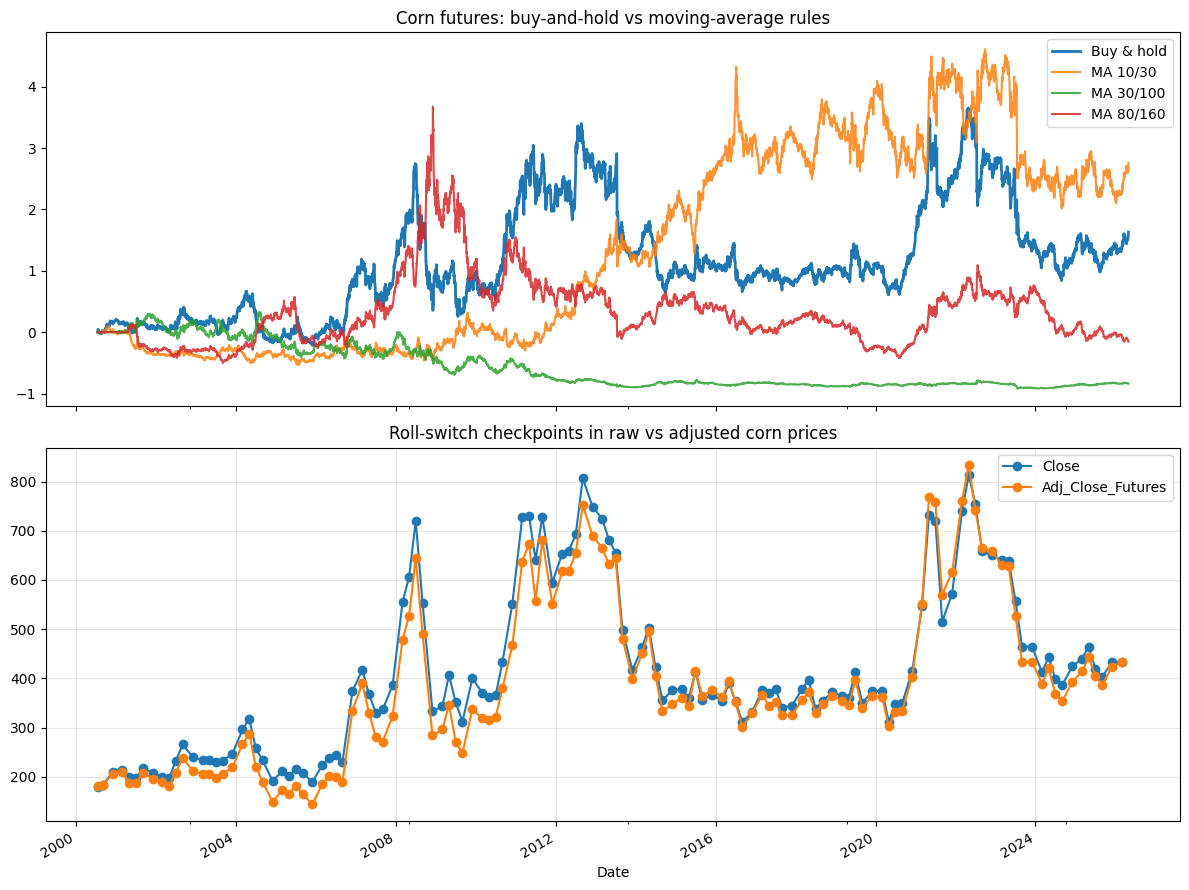

In [3]:
start_date = "2000-02-18"
if CORN_CACHE_PATH.exists() and not REFRESH_CORN_FROM_YAHOO:
    corn = pd.read_csv(CORN_CACHE_PATH, parse_dates=["Date"]).set_index("Date").sort_index()
    print(f"Loaded cached corn series from {CORN_CACHE_PATH}")
else:
    corn = yf.download("ZC=F", start=start_date, auto_adjust=False, progress=False, actions=False)
    if corn.empty:
        raise RuntimeError("yfinance returned no corn futures data. If you want a CSV-only workflow, set REFRESH_CORN_FROM_YAHOO = False and use a populated corn cache.")
    corn = normalize_yfinance_frame(corn)
    corn = back_adjust_continuous_futures(corn)
    corn = add_ma_signals(corn, MA_PAIRS)
    corn.to_csv(CORN_CACHE_PATH)

baseline_summaries = [summarize_strategy("buy_and_hold", corn["futures_ret"])]
for short_window, long_window in MA_PAIRS:
    strat_col = f"strategy_ret_{short_window}_{long_window}"
    signal_col = f"signal_{short_window}_{long_window}"
    baseline_summaries.append(
        summarize_strategy(
            f"ma_{short_window}_{long_window}",
            corn[strat_col],
            corn[signal_col],
        )
    )

baseline_summary = pd.DataFrame(baseline_summaries).set_index("strategy").round(4)
print(baseline_summary)

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
((1 + corn["futures_ret"].fillna(0)).cumprod() - 1).plot(ax=axes[0], label="Buy & hold", linewidth=2)
for short_window, long_window in MA_PAIRS:
    strat_col = f"strategy_ret_{short_window}_{long_window}"
    label = f"MA {short_window}/{long_window}"
    ((1 + corn[strat_col].fillna(0)).cumprod() - 1).plot(ax=axes[0], label=label, alpha=0.85)
axes[0].set_title("Corn futures: buy-and-hold vs moving-average rules")
axes[0].legend()

roll_view = corn.loc[corn["is_roll_switch"], ["Close", "Adj_Close_Futures", "roll_gap"]].copy()
if not roll_view.empty:
    roll_view[["Close", "Adj_Close_Futures"]].plot(ax=axes[1], marker="o")
axes[1].set_title("Roll-switch checkpoints in raw vs adjusted corn prices")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## MOD13A2 NDVI Overlay

The NDVI overlay is intentionally simple:

- low NDVI z-score = crop stress = bullish corn
- high NDVI z-score = healthy vegetation = bearish corn
- apply the overlay to the primary `30/100` technical rule only

Overlay behavior:

- full size when technical and NDVI agree
- half size when NDVI is neutral
- flat when NDVI conflicts with the technical signal


Loaded cached NDVI means from /Users/jlaw/projects/stern/systematic-investing/data/ag_futures/processed/mod13a2_ndvi_level_series.csv
                      obs  cum_return  ann_sharpe  ann_vol  max_drawdown  \
strategy                                                                   
buy_and_hold         6434      1.4893      0.2708   0.3080       -0.6644   
ma_30_100            6334     -0.8297     -0.0718   0.3096       -0.9389   
ma_30_100_plus_ndvi  6334      1.8663      0.3016   0.2162       -0.6469   

                     active_share  
strategy                           
buy_and_hold                  NaN  
ma_30_100                  1.0000  
ma_30_100_plus_ndvi        0.5755  


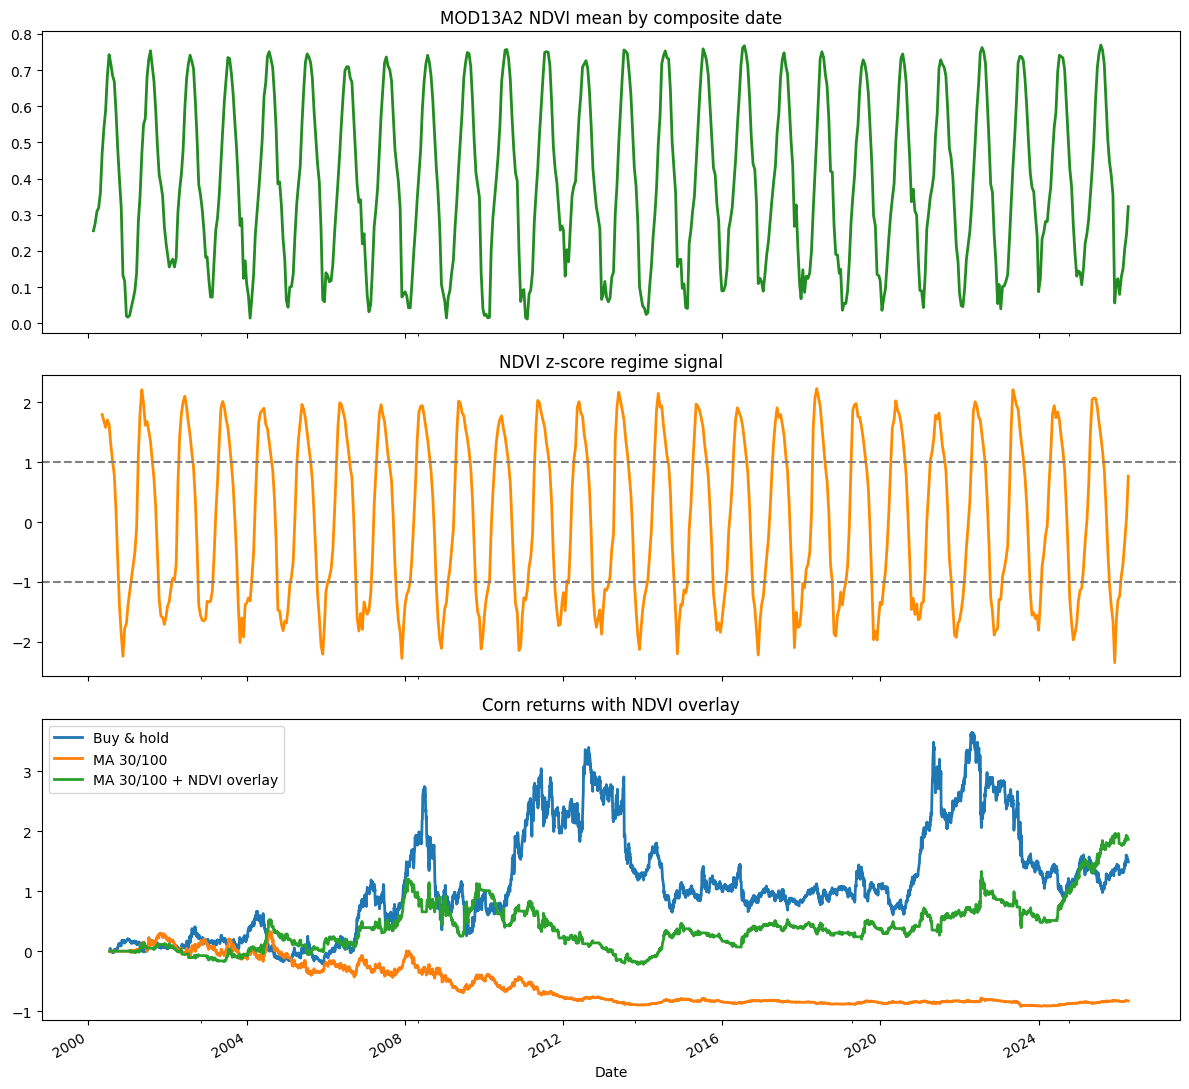

In [4]:
PRIMARY_SIGNAL_COL = f"signal_{PRIMARY_PAIR[0]}_{PRIMARY_PAIR[1]}"
PRIMARY_RET_COL = f"strategy_ret_{PRIMARY_PAIR[0]}_{PRIMARY_PAIR[1]}"

if ndvi_blockers:
    ndvi_level = pd.DataFrame(columns=["ndvi", "ndvi_roll_mean", "ndvi_roll_std", "ndvi_z", "ndvi_regime"])
    ndvi_daily = ndvi_level.copy()
    overlay_summary = pd.DataFrame([{"status": "blocked", "detail": " | ".join(ndvi_blockers)}])
    print("Skipping NDVI overlay because the current dataset is not implementation-ready.")
    print(overlay_summary.to_string(index=False))
else:
    ndvi_level, ndvi_daily = load_ndvi_series(ndvi_inventory)

    analysis = corn.join(ndvi_daily[["ndvi", "ndvi_z", "ndvi_regime"]], how="inner")
    if analysis.empty:
        raise RuntimeError("NDVI dates and corn futures dates do not overlap after alignment.")

    analysis["overlay_signal"] = np.where(
        analysis[PRIMARY_SIGNAL_COL].isna(),
        np.nan,
        np.where(
            analysis["ndvi_regime"] == analysis[PRIMARY_SIGNAL_COL],
            analysis[PRIMARY_SIGNAL_COL],
            np.where(analysis["ndvi_regime"] == 0.0, 0.5 * analysis[PRIMARY_SIGNAL_COL], 0.0),
        ),
    )
    analysis["overlay_ret"] = analysis["overlay_signal"].shift(1) * analysis["futures_ret"]
    analysis.to_csv(PROCESSED_DIR / "corn_ndvi_overlay_panel.csv")

    overlay_summary = pd.DataFrame(
        [
            summarize_strategy("buy_and_hold", analysis["futures_ret"]),
            summarize_strategy(
                f"ma_{PRIMARY_PAIR[0]}_{PRIMARY_PAIR[1]}",
                analysis[PRIMARY_RET_COL],
                analysis[PRIMARY_SIGNAL_COL],
            ),
            summarize_strategy("ma_30_100_plus_ndvi", analysis["overlay_ret"], analysis["overlay_signal"]),
        ]
    ).set_index("strategy").round(4)
    print(overlay_summary)

    fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
    ndvi_level["ndvi"].plot(ax=axes[0], color="forestgreen", linewidth=2)
    axes[0].set_title("MOD13A2 NDVI mean by composite date")
    ndvi_level["ndvi_z"].plot(ax=axes[1], color="darkorange", linewidth=2)
    axes[1].axhline(-1.0, color="gray", linestyle="--")
    axes[1].axhline(1.0, color="gray", linestyle="--")
    axes[1].set_title("NDVI z-score regime signal")
    ((1 + analysis["futures_ret"].fillna(0)).cumprod() - 1).plot(ax=axes[2], label="Buy & hold", linewidth=2)
    ((1 + analysis[PRIMARY_RET_COL].fillna(0)).cumprod() - 1).plot(ax=axes[2], label="MA 30/100", linewidth=2)
    ((1 + analysis["overlay_ret"].fillna(0)).cumprod() - 1).plot(ax=axes[2], label="MA 30/100 + NDVI overlay", linewidth=2)
    axes[2].set_title("Corn returns with NDVI overlay")
    axes[2].legend()
    plt.tight_layout()
    plt.show()


## Current Interpretation and Next Step

- If the NDVI section is skipped, that is expected when either the HDF4 parser is missing or the current Earthdata pull is too short.
- Right now the notebook is still useful because it gives you the finished corn baseline, the roll-adjustment logic, the overlay specification, and the exact blockers.
- The next productive move is to keep the current MOD13A2 history and rerun this notebook whenever you refresh the vegetation data.
- If HDF4 becomes annoying, switch the NDVI subset workflow to AppEEARS NetCDF so the overlay can be activated without a specialized HDF4 reader.
